# Tytuł

About

1.  **Fixed acidity** – Kwasowość stała (związana z kwasami, które naturalnie występują w winogronach i nie odparowują).
2.  **Volatile acidity** – Kwasowość lotna (jej nadmiar nadaje winu nieprzyjemny, octowy posmak).
3.  **Citric acid** – Kwas cytrynowy.
4.  **Residual sugar** – Cukier resztkowy (ilość cukru, która pozostaje w winie po zakończeniu fermentacji).
5.  **Chlorides** – Chlorki (określają poziom soli w winie).
6.  **Free sulfur dioxide** – Wolny dwutlenek siarki.
7.  **Total sulfur dioxide** – Całkowity dwutlenek siarki.
8.  **Density** – Gęstość (zależy od zawartości alkoholu i cukru).
9.  **pH** – Mierzy kwasowość wina (większość win na świecie mieści się w przedziale 3.0 – 4.0).
10. **Sulphates** – Siarczany (dodatki, które mogą zwiększać poziom wolnego dwutlenku siarki).
11. **Alcohol** – Zawartość alkoholu w procentach.
12. **Quality** - Ocena jakości wina (skala od 3 do 8, gdzie 3 oznacza najgorsze, a 8 najlepsze wino).
13. **Quality_bin** - Binarna ocena jakości wina. 0 - słabe (quality<7), 1 - dobre (quality>=7).

# EDA

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.helpers import create_percentage_plot, quality_based_plot

In [4]:
df = pd.read_csv("data/winequality-red.csv", sep=";")

In [5]:
# Dodanie kolumny do binaryzacji
df['quality_bin'] = np.astype((df['quality'] >= 7).to_numpy(), np.int8)

## Ogólne informacje

In [6]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_bin
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [7]:
df.shape

(1599, 13)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_bin           1599 non-null   int8   
dtypes: float64(11), int64(1), int8(1)
memory usage: 151.6 KB


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Poniżej widać, że nie mamy żadnych brakujących danych.

In [10]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_bin             0
dtype: int64

<Axes: >

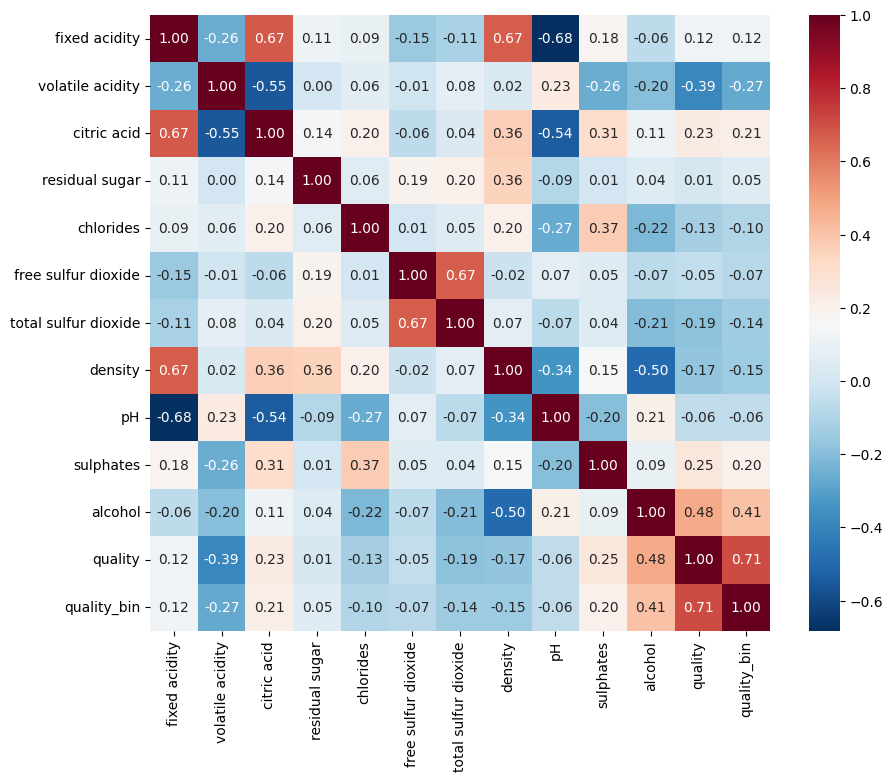

In [87]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r')

## quality

In [11]:
df['quality'].sort_values().unique()

array([3, 4, 5, 6, 7, 8])

Dane są drastycznie niezbalansowane.

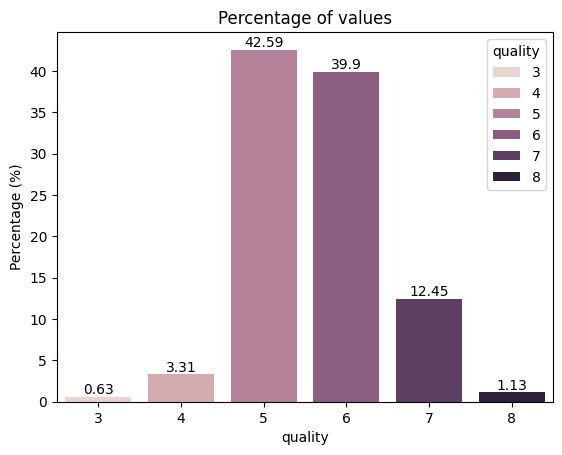

In [12]:
create_percentage_plot(df['quality'], bar_label=True)

<Axes: >

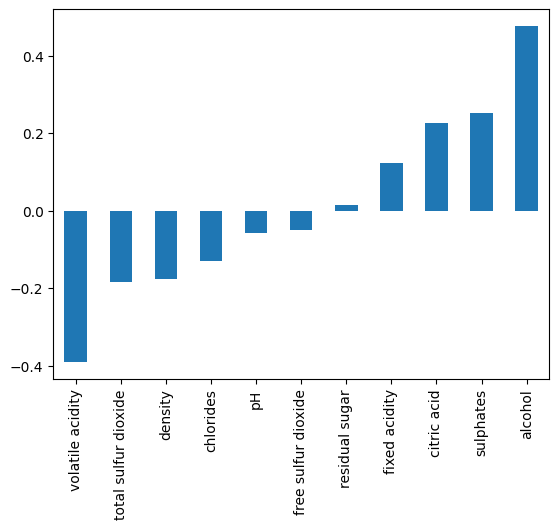

In [80]:
df.drop(['quality_bin'], axis=1).corr()['quality'][:-1].sort_values().plot(kind='bar')

Text(0.5, 1.0, 'Outliers')

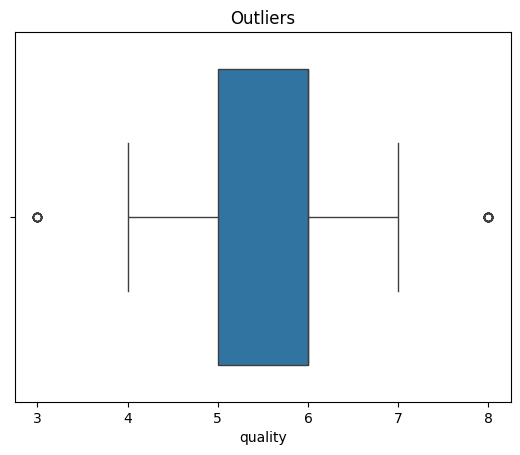

In [13]:
sns.boxplot(df, x='quality')
plt.title("Outliers")

## quality_bin

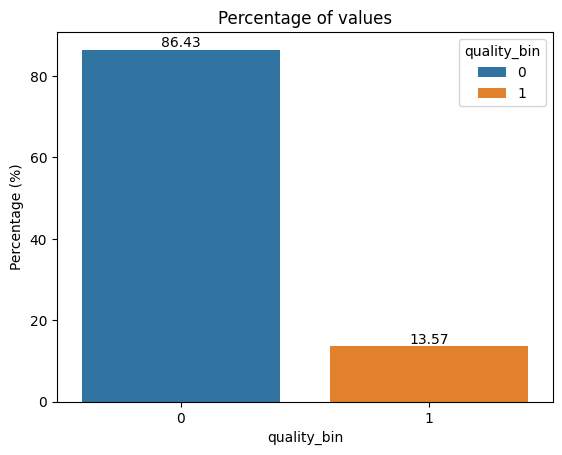

In [14]:
create_percentage_plot(df['quality_bin'], bar_label=True)

<Axes: >

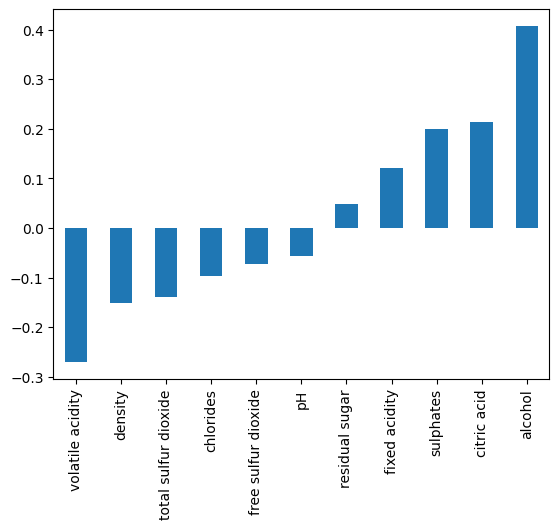

In [78]:
df.drop(['quality'], axis=1).corr()['quality_bin'][:-1].sort_values().plot(kind='bar')

## fixed acidity

Brak trendu dla tej cechy.

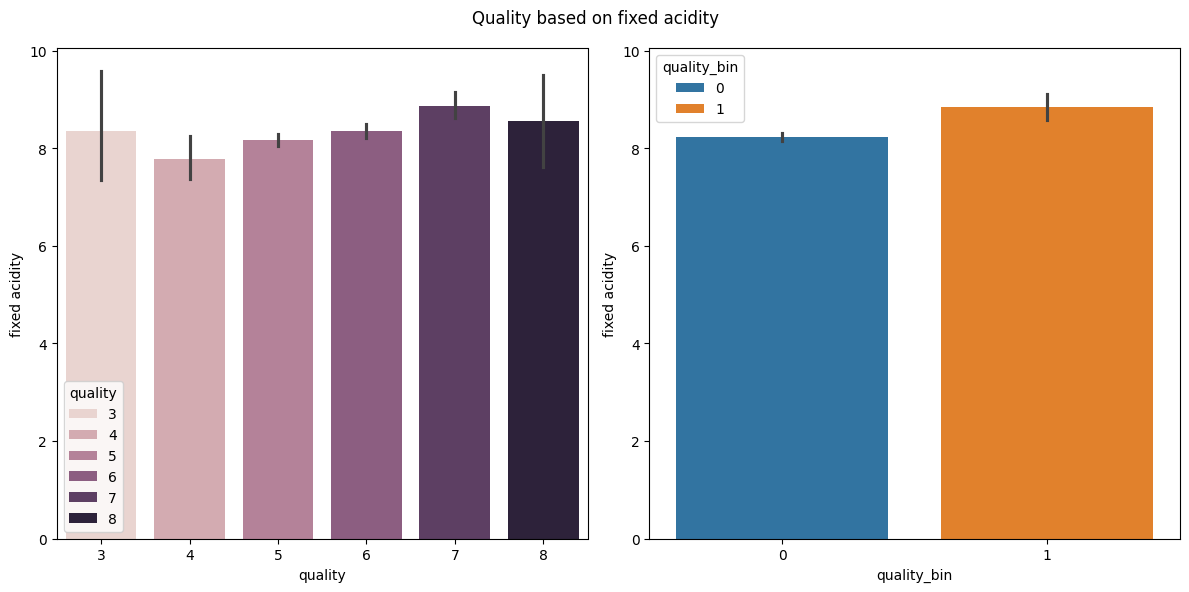

In [16]:
quality_based_plot(df, 'fixed acidity')

Poniżej widać kilka wartości odstających. W kontekście winiarskim są to naturalne wariacje produktu.

Text(0.5, 1.0, 'Outliers')

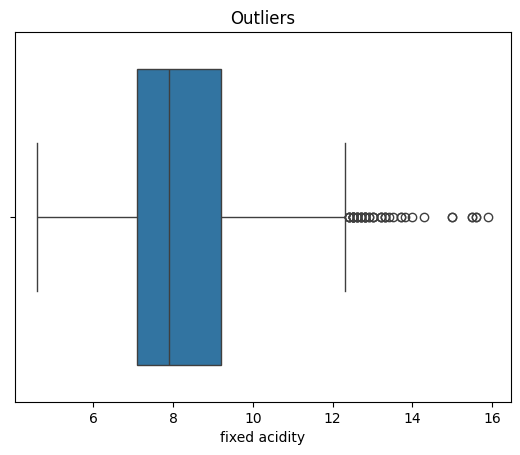

In [18]:
sns.boxplot(df, x='fixed acidity')
plt.title("Outliers")

In [32]:
df[df['fixed acidity']>12.5][['quality', 'quality_bin']].value_counts()

quality  quality_bin
6        0              17
5        0              11
7        1               9
8        1               1
Name: count, dtype: int64

## volatile acidity

Poniżej można zauważyć zależność między tą cechą a jakością wina. Im wyższa kwasowość lotna, tym gorsze wino.

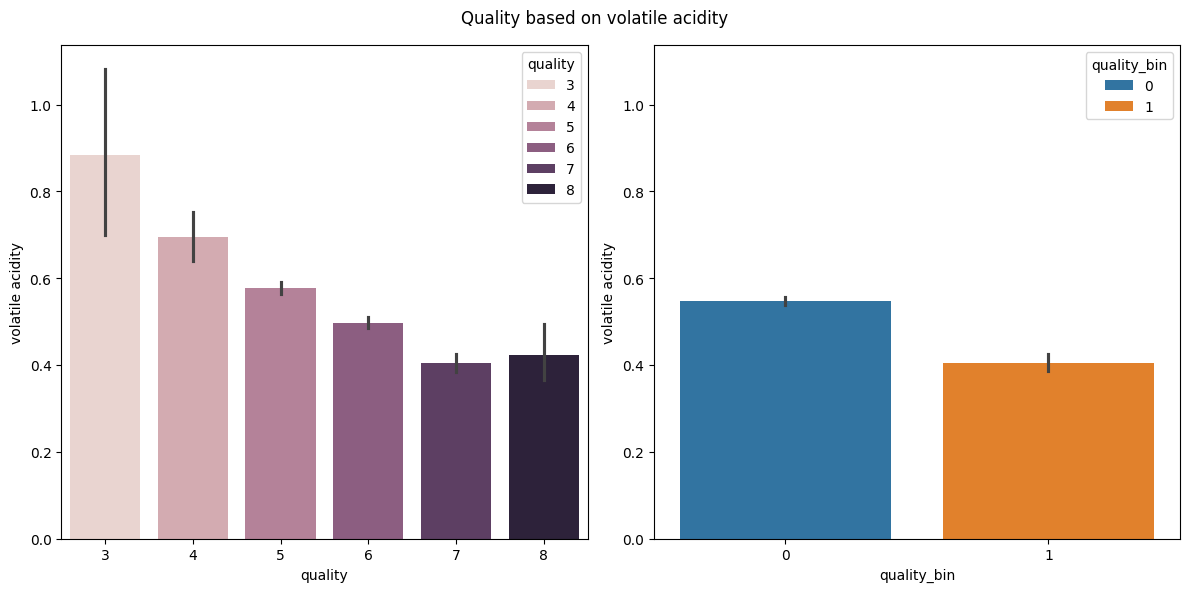

In [27]:
quality_based_plot(df, 'volatile acidity')

A podobnie jak w poprzednim wypadku, progi są akceptowalne.

Text(0.5, 1.0, 'Outliers')

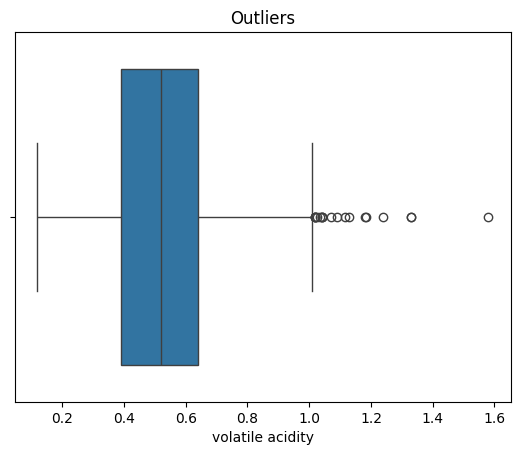

In [33]:
sns.boxplot(df, x='volatile acidity')
plt.title("Outliers")

## citric acid

Trend rosnący, im więcej kwasu cytrynowego, tym lepsze wino.

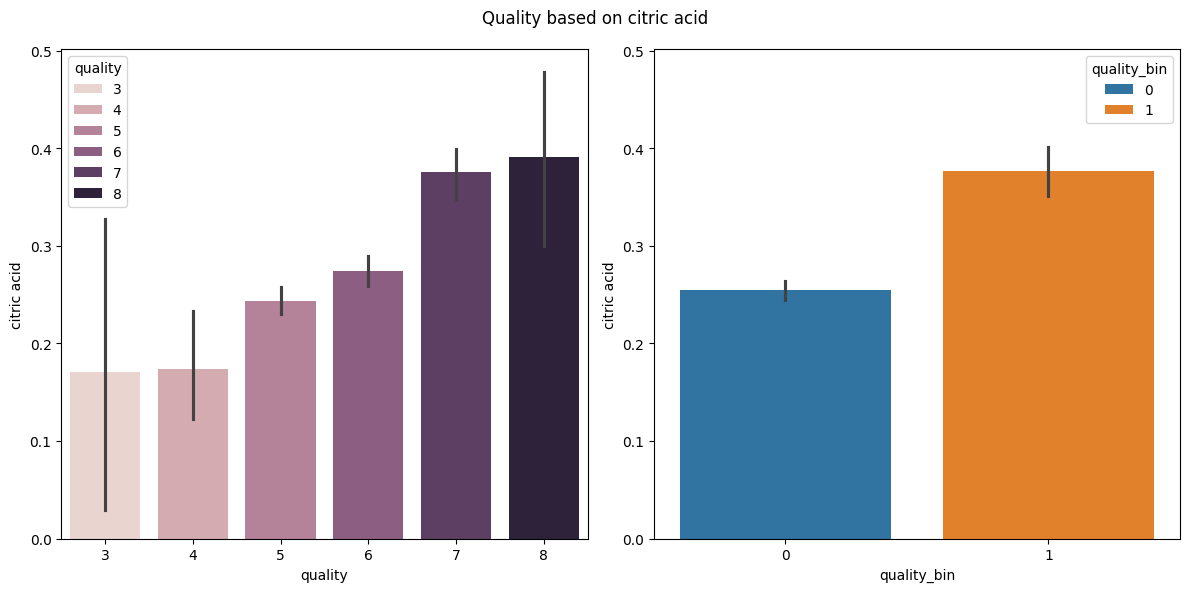

In [35]:
quality_based_plot(df, 'citric acid')

Text(0.5, 1.0, 'Outliers')

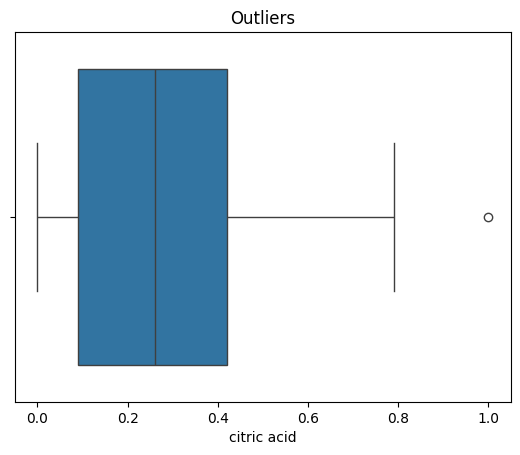

In [37]:
sns.boxplot(df, x='citric acid')
plt.title("Outliers")

## residual sugar

Brak trendu dla tej cechy.

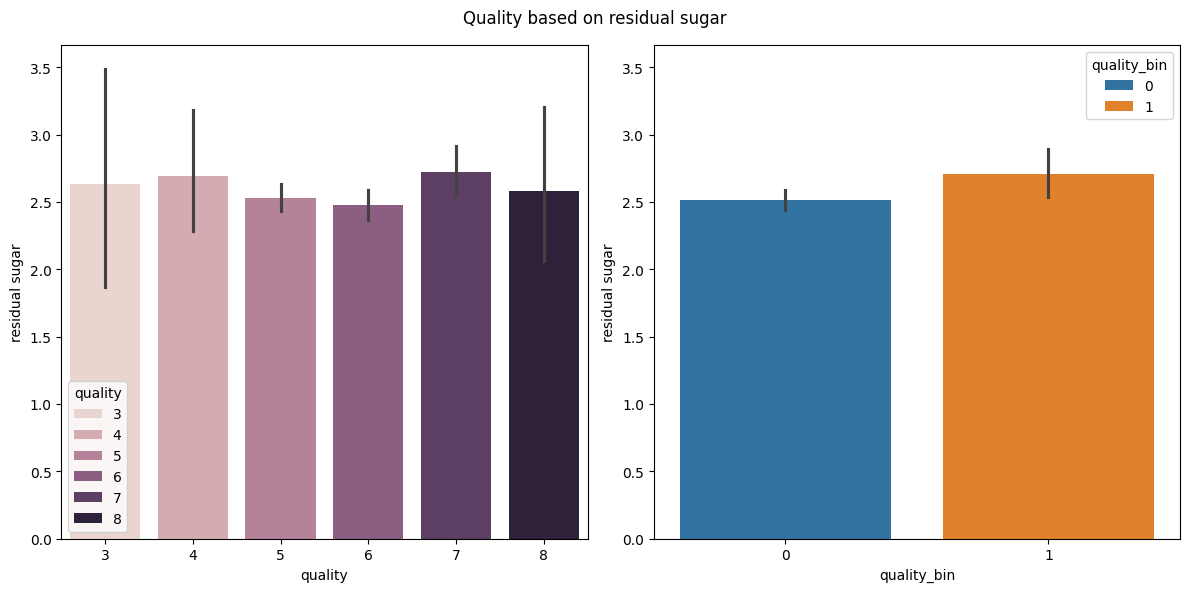

In [38]:
quality_based_plot(df, 'residual sugar')

Poniżej widać sporo wartości odstających, ale w kontekście winiarskim jest to normalne. To po prostu wina półwytrawne lub rzadsze, słodsze warianty czerwonego wina.

Text(0.5, 1.0, 'Outliers')

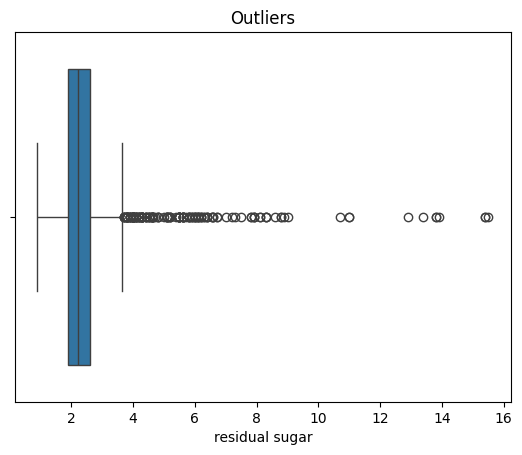

In [39]:
sns.boxplot(df, x='residual sugar')
plt.title("Outliers")

In [40]:
df[df['residual sugar']>4][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              53
6        0              36
7        1              25
4        0               7
8        1               2
3        0               2
Name: count, dtype: int64

## chlorides

Widać zależność między tą cechą a jakością wina. Im więcej chlorków, tym gorsze wino.

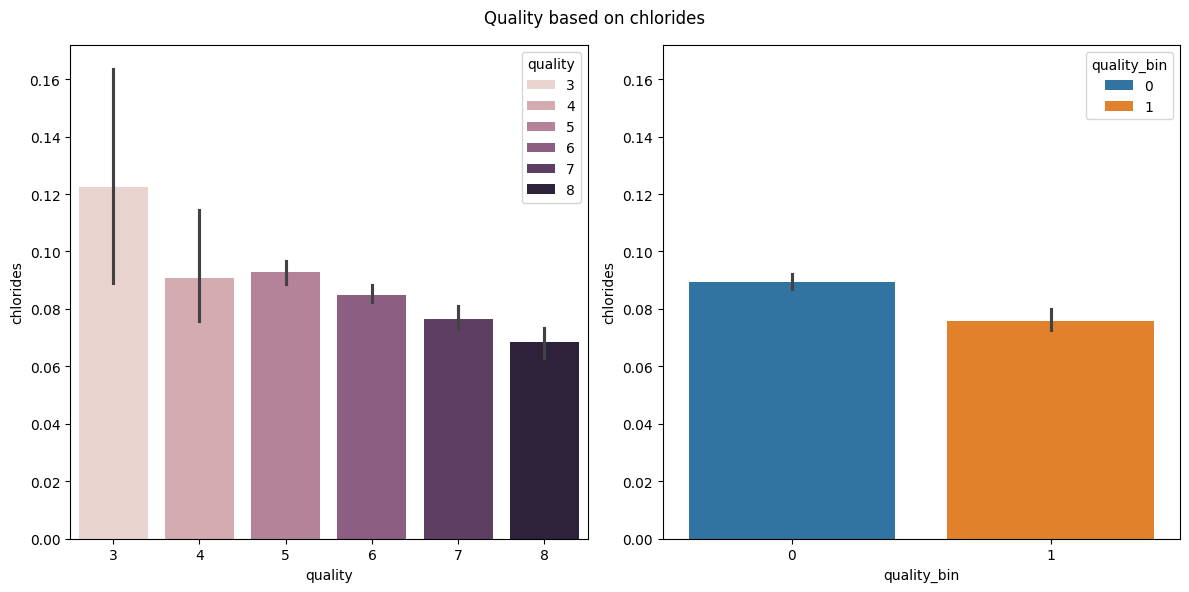

In [41]:
quality_based_plot(df, 'chlorides')

Poniżej znowu widać sporą ilość wartości odstających. Wartości te to naturalne wariacje chemiczne wina. Mogą to być wina z winnic położonych w specyficznych regionach (np. bliżej oceanu lub na glebach bogatych w minerały).

Text(0.5, 1.0, 'Outliers')

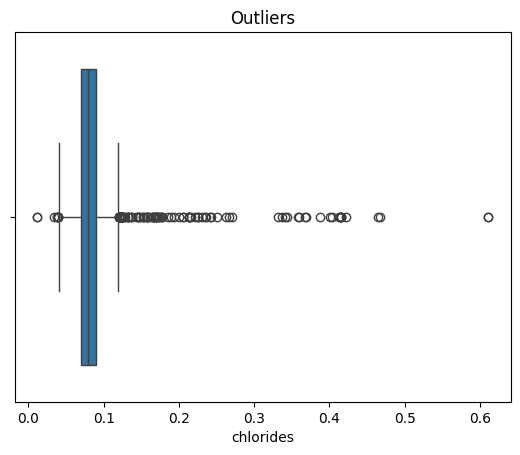

In [43]:
sns.boxplot(df, x='chlorides')
plt.title("Outliers")

In [44]:
df[df['chlorides']>0.13][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              38
6        0              30
3        0               4
4        0               3
7        1               3
Name: count, dtype: int64

## free sulfur dioxide

Brak trendu dla tej cechy.

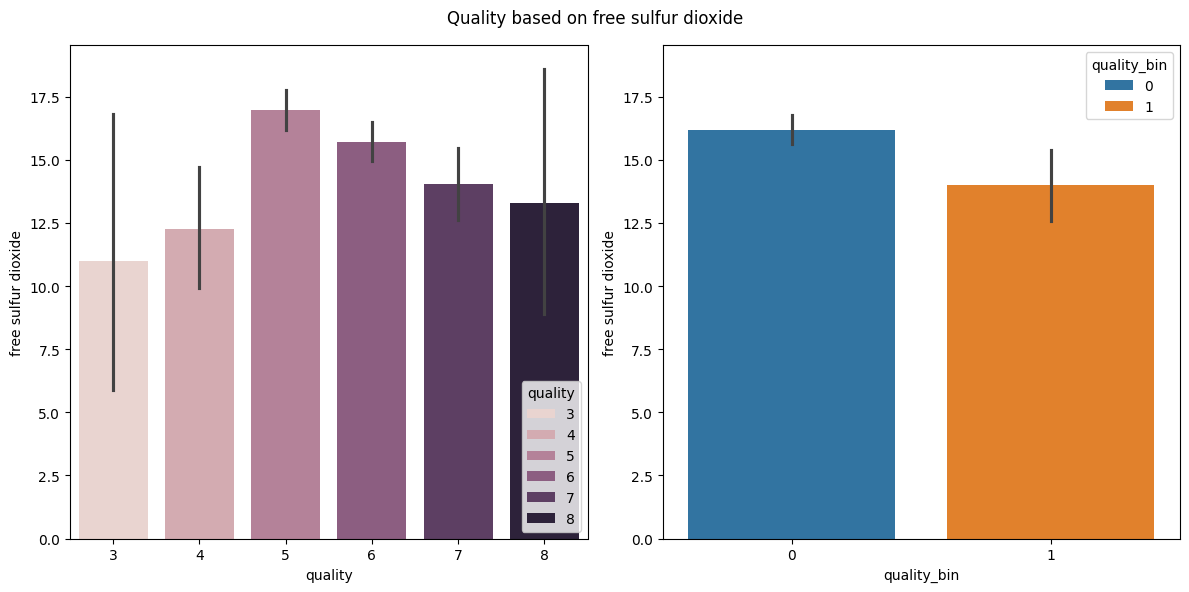

In [45]:
quality_based_plot(df, 'free sulfur dioxide')

Są to prawdziwe wartości odstające i nie jest ich dużo.

Text(0.5, 1.0, 'Outliers')

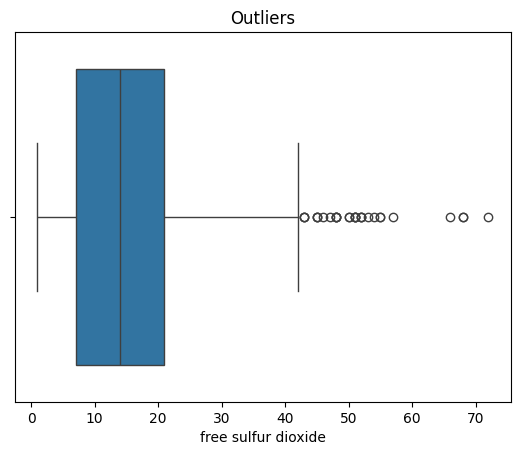

In [47]:
sns.boxplot(df, x='free sulfur dioxide')
plt.title("Outliers")

In [56]:
df[df['free sulfur dioxide']>43][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              16
6        0               7
7        1               4
Name: count, dtype: int64

## total sulfur dioxide

Podobnie, brak trendu.

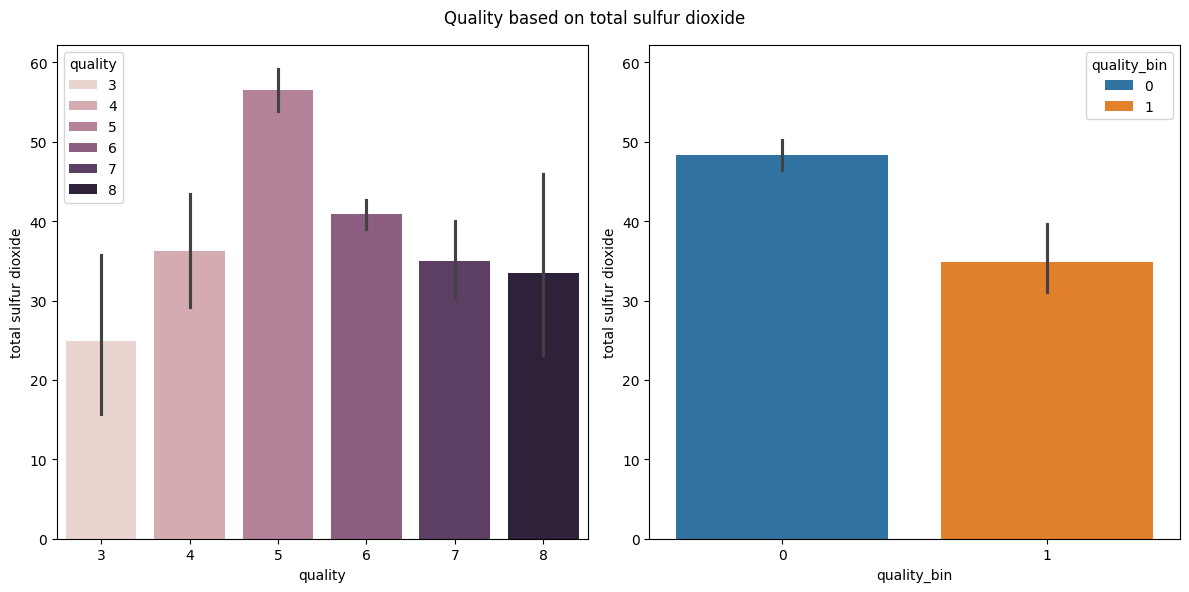

In [48]:
quality_based_plot(df, 'total sulfur dioxide')

Poniżej widać dwie skrajnie odstające wartości. Po analizie zdecydowałem je zostawić ze względu na wysoką ocenę jakości wina i na fakt, że w kontekście winiarskim takie wartości są możliwe.

Text(0.5, 1.0, 'Outliers')

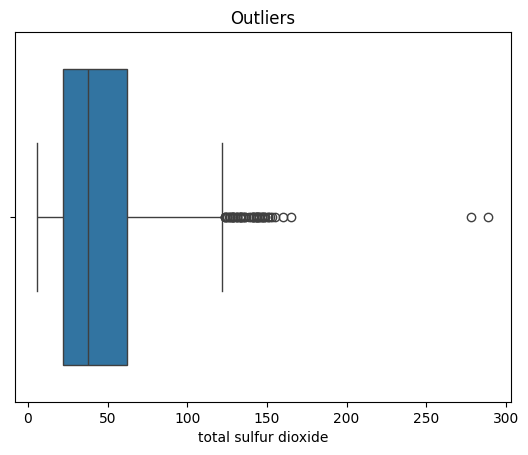

In [49]:
sns.boxplot(df, x='total sulfur dioxide')
plt.title("Outliers")

In [51]:
df[(df['total sulfur dioxide']>120) & (df['total sulfur dioxide']<200)][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              54
6        0               6
Name: count, dtype: int64

In [58]:
df[df['total sulfur dioxide']>250][['quality', 'quality_bin']].value_counts()

quality  quality_bin
7        1              2
Name: count, dtype: int64

In [59]:
df[df['total sulfur dioxide']>250]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_bin
1079,7.9,0.3,0.68,8.3,0.05,37.5,278.0,0.99316,3.01,0.51,12.3,7,1
1081,7.9,0.3,0.68,8.3,0.05,37.5,289.0,0.99316,3.01,0.51,12.3,7,1


## density

Wszystkie wina w zbiorze danych mają gęstość bardzo zbliżoną do 1.

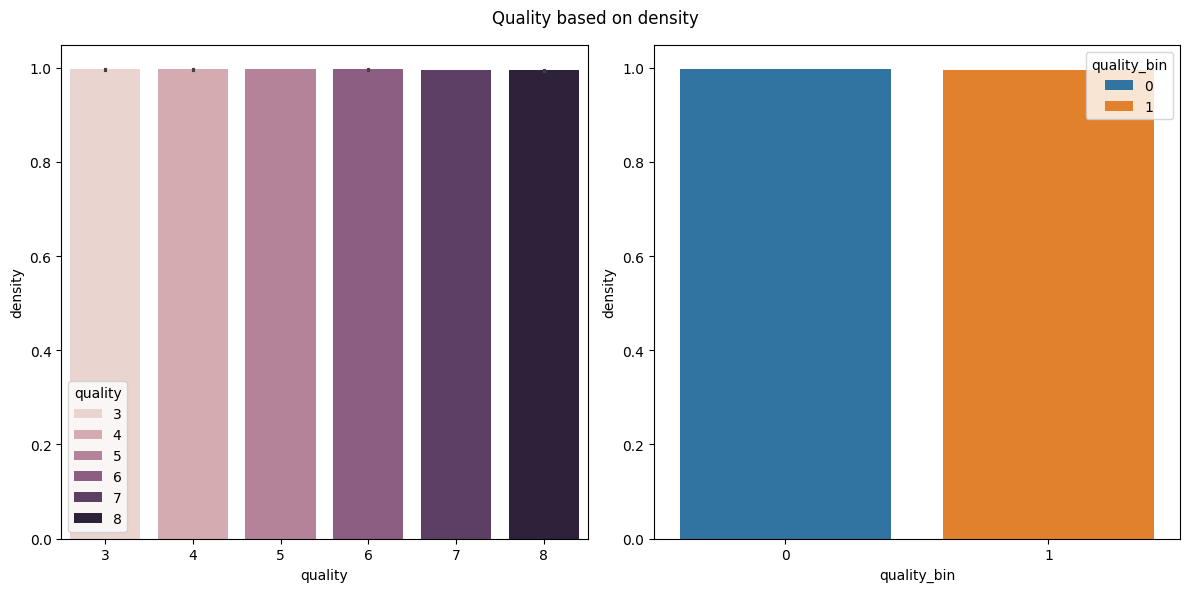

In [60]:
quality_based_plot(df, 'density')

Zbyt mikroskopijna skala żeby usuwać wartości odstające.

Text(0.5, 1.0, 'Outliers')

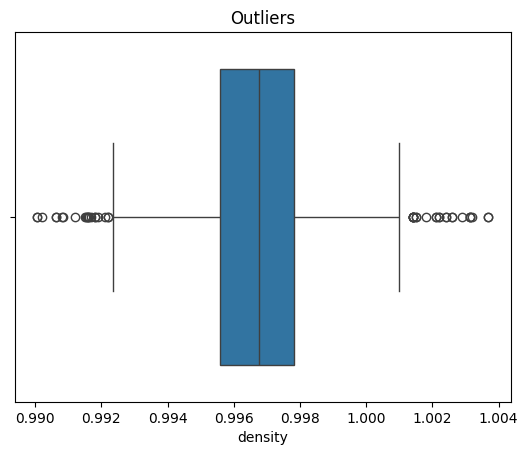

In [62]:
sns.boxplot(df, x='density')
plt.title("Outliers")

## pH

Brak większych różnic między winami o różnej jakości. Wina o wyższej jakości mają nieco niższe pH, ale różnica jest minimalna.

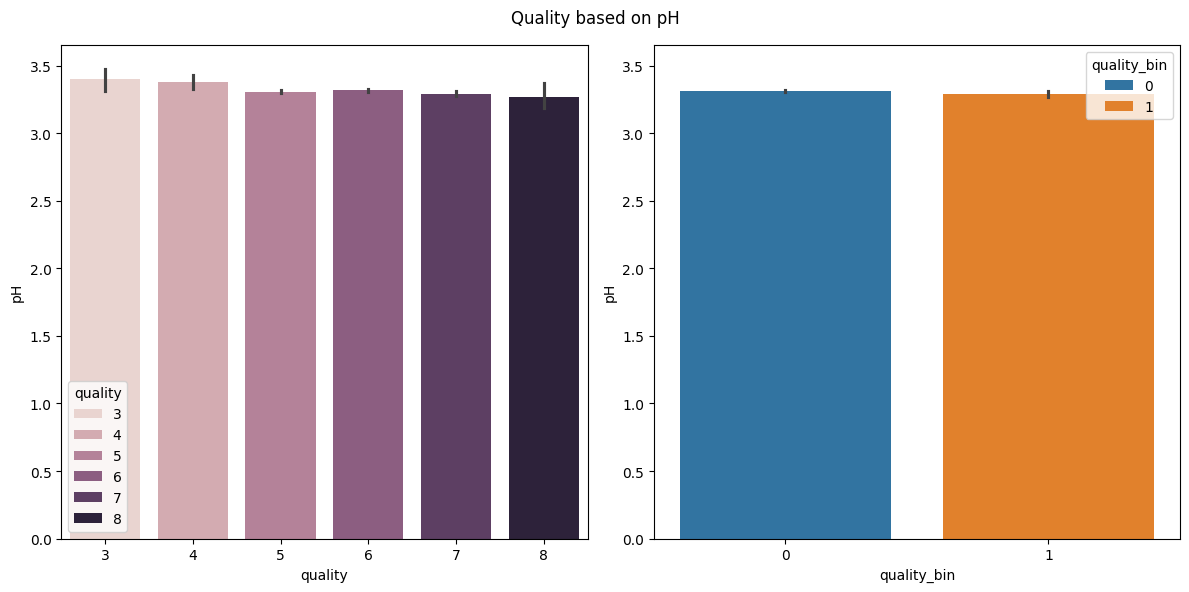

In [63]:
quality_based_plot(df, 'pH')

Nie duża liczba wartości odstających. Większość win ma pH między 3 a 4, a więc takie wartości odstające są naturalne.

Text(0.5, 1.0, 'Outliers')

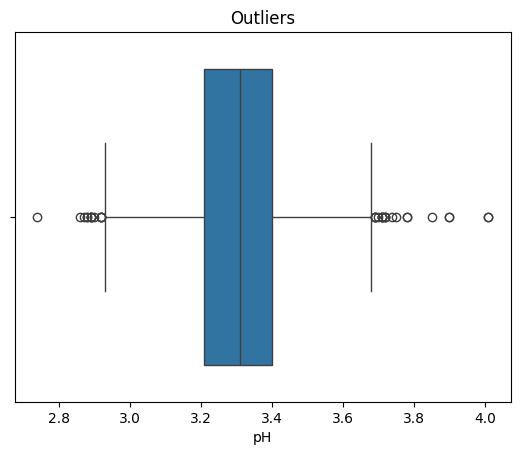

In [65]:
sns.boxplot(df, x='pH')
plt.title("Outliers")

## sulphates

Widoczny trend rosnący, im więcej siarczanów, tym lepsze wino.

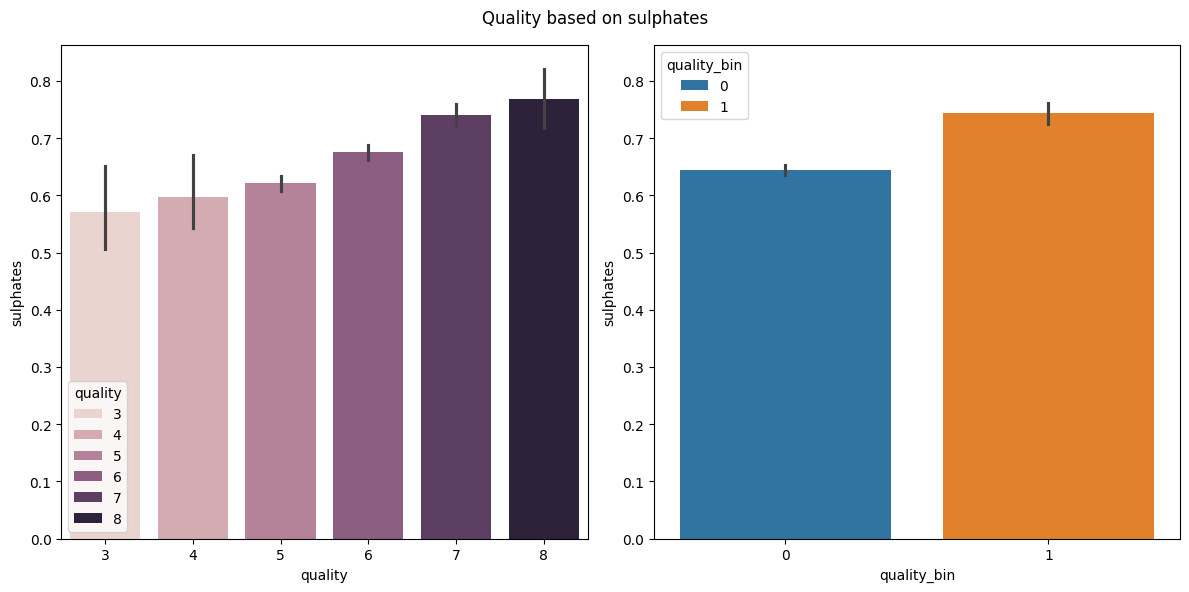

In [66]:
quality_based_plot(df, 'sulphates')

Naturalne wartości odstające, które mogą wynikać z różnych technik produkcji wina lub różnic w składzie chemicznym winogron.

Text(0.5, 1.0, 'Outliers')

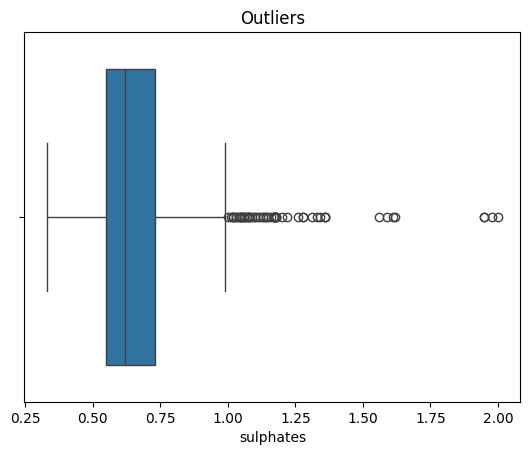

In [67]:
sns.boxplot(df, x='sulphates')
plt.title("Outliers")

## alcohol

Wina z wyższą zawartością alkoholu są oceniane jako lepsze.

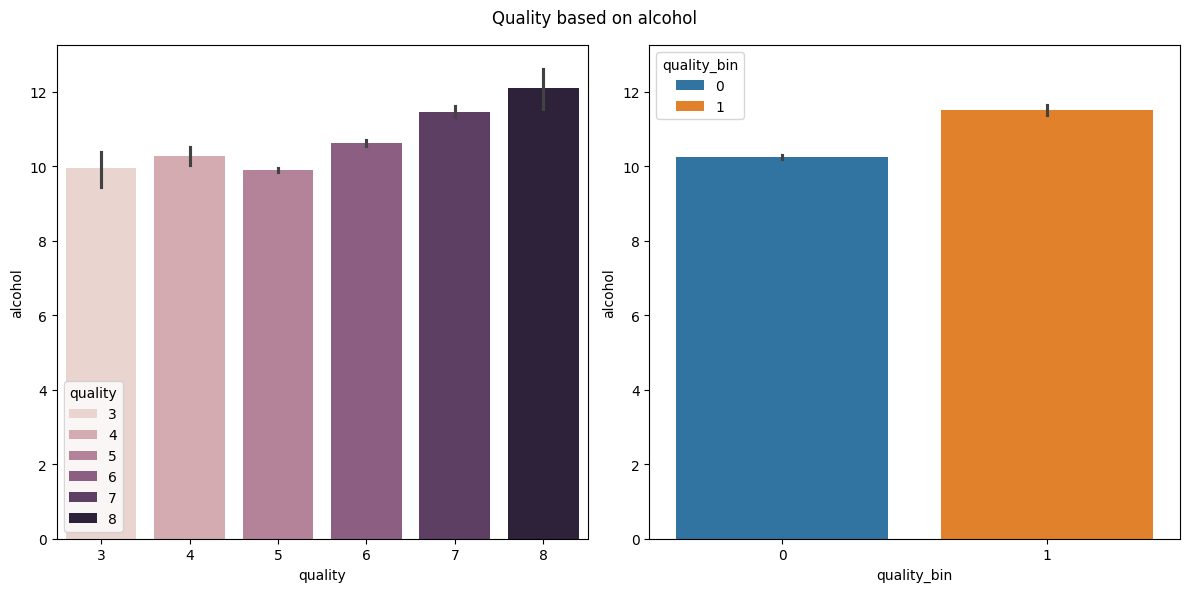

In [68]:
quality_based_plot(df, 'alcohol')

Akceptowalna liczba wartości odstających.

Text(0.5, 1.0, 'Outliers')

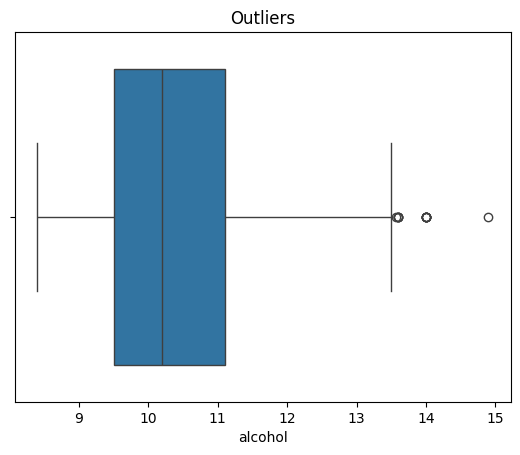

In [69]:
sns.boxplot(df, x='alcohol')
plt.title("Outliers")

## Podsumowanie EDA

Zbiór danych okazał się kompletny i pozbawiony braków (null values), co pozwoliło na płynne przejście do analizy rozkładów. W tym przypadku zostały napotkane dwa główne problemy: niezbalansowane dane oraz spora obecność wartości odstających. Niezbalansowanie danych, cechy 'quality', może prowadzić do problemów z uczeniem modelów, ponieważ mogą one być stronnicze wobec dominujących klas. Natomiast obecność naturalnych wartości odstających, które postanowiłem pozostawić ze względu na ich autentyczność w kontekście winiarskim, może być zagrożniem dla modeli opartych na odległościach, takich jak np. KNN czy SVC. Dlatego też trzeba będzie wykorzystać scaler, który jest odporny na wartości odstające, np. RobustScaler. Mimo tych problemów, analiza rozkładów pozwoliła na zidentyfikowanie kilku interesujących zależności między cechami a jakością wina, co może być cenne przy budowie modeli predykcyjnych.